# Prediction & Optimization of PLTP Net Power Output using Polynomial Regression and Metaheuristic Optimization (SA, PSO, Hybrid PSO-SA)

**Note:** This notebook merges two research notebooks:
1. The full pipeline — data loading, feature engineering, EDA, polynomial regression model selection, through to baseline optimization with SA, PSO, and Hybrid PSO-SA.


## 1. Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import time
from matplotlib.patches import Ellipse

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (r2_score, mean_absolute_error,
                              mean_squared_error, mean_absolute_percentage_error)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)


## 2. Loading Raw Data


In [ ]:
wb = openpyxl.load_workbook('Data_TA_.xlsx', data_only=True)
ws = wb['Sheet1']
names = [ws.cell(2, c).value for c in range(2, 104)]
data = [[ws.cell(r, c).value for c in range(2, 104)] for r in range(4, 2909)]
df_raw = pd.DataFrame(data, columns=names)
print("Raw data size:", df_raw.shape)

df = df_raw.dropna(axis=1, how='all')
print("After dropping 100%-empty columns (unattached sensors):", df.shape)


Raw data size: (2905, 102)
After dropping 100%-empty columns (unattached sensors): (2905, 45)


## 3. Correlation Analysis & Feature Selection

### 3.1 Full Correlation with the Target


In [ ]:
num_df = df.drop(columns=['Timestamp'])
corr_full = num_df.corr()['nett power (mw)'].sort_values(ascending=False)
print(corr_full.head(10))


nett power (mw)                   1.000000
gross power (mw)                  0.996372
laju inlet turbin (t/h)           0.944677
tekanan outlet turbin A (bara)    0.566726
tekanan outlet turbin B (bara)    0.562994
tekanan outlet turbin C (bara)    0.561891
tekanan inlet HWP A (barg)        0.452623
tekanan inlet HWP B (barg)        0.438042
tekanan inlet air ke CT (barg)    0.394318
suhu inlet air ke CT (degC)       0.360130
Name: nett power (mw), dtype: float64


### 3.2 Representative Feature Engineering (Sensor Deduplication)

Redundant multi-point sensors (`turbine outlet pressure A/B/C`, `HWP inlet pressure A/B`) are combined by averaging before the multicollinearity test.


In [ ]:
df['tekanan outlet turbin (bara)'] = df[[
    'tekanan outlet turbin A (bara)', 'tekanan outlet turbin B (bara)', 'tekanan outlet turbin C (bara)'
]].mean(axis=1)
df['tekanan inlet HWP (barg)'] = df[[
    'tekanan inlet HWP A (barg)', 'tekanan inlet HWP B (barg)'
]].mean(axis=1)
print("Representative features successfully created.")


Representative features successfully created.


### 3.3 Multicollinearity Test (VIF) — Key Elimination Criterion

**This is the critical step that distinguishes this final version from the earlier one (4-7 features):** high correlation with the target alone is not enough — the selected features must also be confirmed **not redundant with each other**. VIF (Variance Inflation Factor) > 5 indicates problematic multicollinearity, and VIF > 10 is severe.


In [ ]:
def compute_vif(X):
    result = []
    for i in range(X.shape[1]):
        y_i = X[:, i]
        X_other = np.delete(X, i, axis=1)
        lr = LinearRegression().fit(X_other, y_i)
        r2 = r2_score(y_i, lr.predict(X_other))
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        result.append(vif)
    return result

candidate_feats = ['laju inlet turbin (t/h)', 'tekanan outlet turbin (bara)',
                    'tekanan inlet HWP (barg)', 'suhu inlet air ke CT (degC)']
vifs = compute_vif(df[candidate_feats].values)
print("VIF of 4 candidate features (high correlation with target):")
for f, v in zip(candidate_feats, vifs):
    print(f"  {f}: VIF = {v:.2f}")


VIF of 4 candidate features (high correlation with target):
  laju inlet turbin (t/h): VIF = 2.20
  tekanan outlet turbin (bara): VIF = 12.29
  tekanan inlet HWP (barg): VIF = 9.08
  suhu inlet air ke CT (degC): VIF = 2.31


**Finding:** `turbine outlet pressure` and `HWP inlet pressure` both have high VIF (12.29 and 9.08) — they explain each other, since thermodynamically they are closely tied to the same cooling system/condenser condition (pairwise correlation reaches 0.94-0.99). Including both at once does not add independent information, only redundancy and a risk of unstable regression coefficients.

**Solution:** keep a single representative of this "condenser" group — `turbine outlet pressure` was chosen because it has a higher correlation with the target (0.57 vs 0.44 for HWP, and 0.36 for CT temperature).


In [ ]:
FEATURES = ['laju inlet turbin (t/h)', 'tekanan outlet turbin (bara)']
TARGET = 'nett power (mw)'

vifs_final = compute_vif(df[FEATURES].values)
print("VIF OF FINAL 2 FEATURES:")
for f, v in zip(FEATURES, vifs_final):
    print(f"  {f}: VIF = {v:.2f}")


VIF OF FINAL 2 FEATURES:
  laju inlet turbin (t/h): VIF = 2.13
  tekanan outlet turbin (bara): VIF = 2.13


**VIF drops to 2.13 for both — far below the problematic threshold (5).** This confirms these 2 features truly carry mutually independent information, rather than repeating the same information.


## 4. Data Preprocessing


In [ ]:
implausible_zero_cols = [c for c in df.columns if c != 'Timestamp' and (df[c] == 0).sum() > 0]
mask_bad = (df[implausible_zero_cols] == 0).any(axis=1)
print("Rows with sensor dropout (anomalous zero values):", mask_bad.sum())

df = df[~mask_bad].reset_index(drop=True)
print("Data size after cleaning:", df.shape)


Rows with sensor dropout (anomalous zero values): 5
Data size after cleaning: (2900, 47)


In [ ]:
model_df = df[FEATURES + [TARGET, 'Timestamp']].copy()

before = len(model_df)
for col in FEATURES + [TARGET]:
    Q1, Q3 = model_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
    model_df = model_df[(model_df[col] >= lo) & (model_df[col] <= hi)]
after = len(model_df)
print(f"Outlier removal (IQR k=3): {before} -> {after} rows")


Outlier removal (IQR k=3): 2900 -> 2900 rows


## 5. Exploratory Data Analysis (EDA)


### 5.1 Net Power Output Time Series


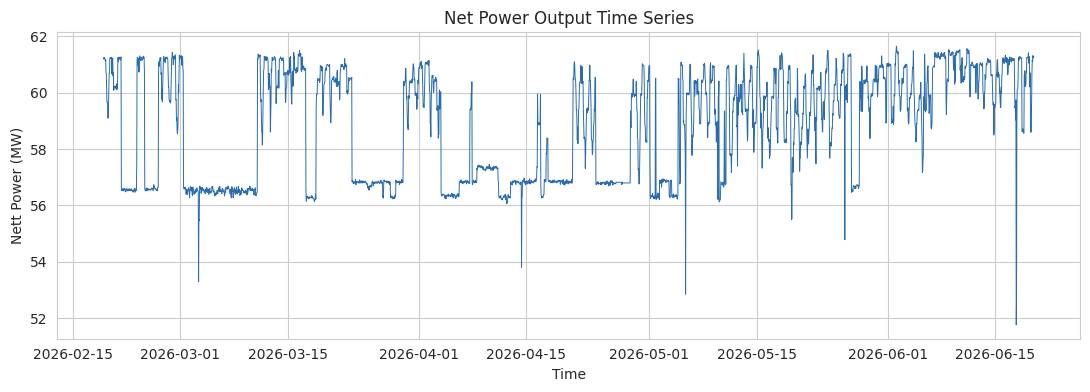

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(model_df['Timestamp'], model_df[TARGET], lw=0.7, color='#2b6cb0')
ax.set_title('Net Power Output Time Series'); ax.set_xlabel('Time'); ax.set_ylabel('Nett Power (MW)')
plt.tight_layout(); plt.show()


### 5.2 Target Distribution


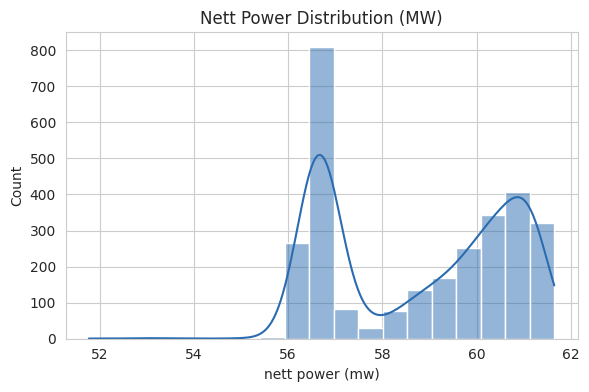

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(model_df[TARGET], kde=True, ax=ax, color='#2b6cb0')
ax.set_title('Nett Power Distribution (MW)')
plt.tight_layout(); plt.show()


### 5.3 Boxplot (Outlier Detection)


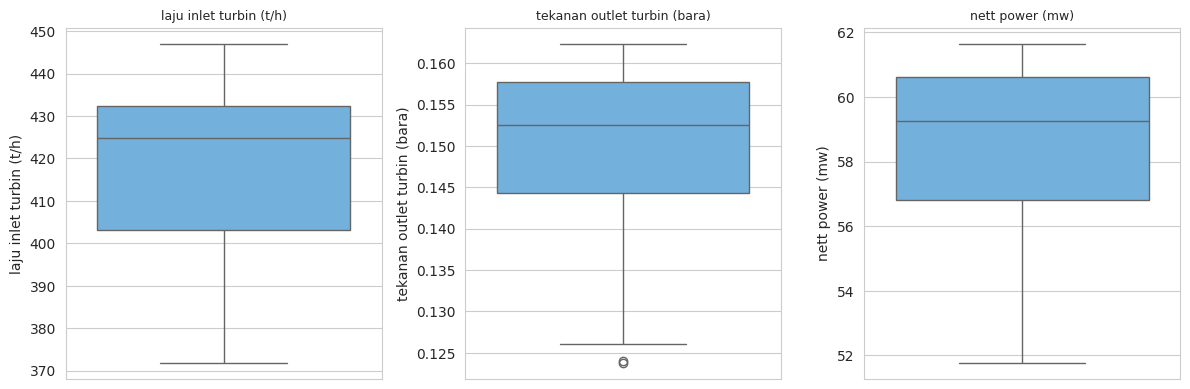

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    sns.boxplot(y=model_df[col], ax=ax, color='#63b3ed')
    ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.show()


### 5.4 Correlation Heatmap


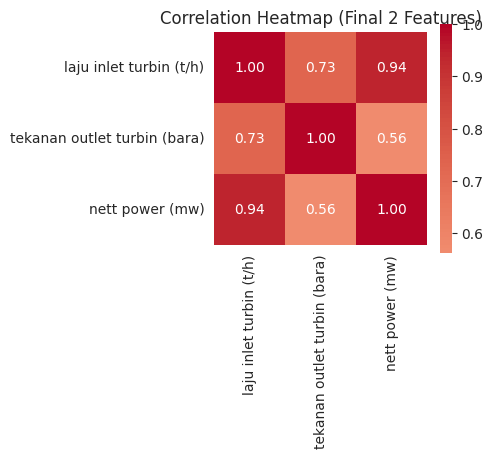

In [ ]:
corr = model_df[FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap (Final 2 Features)')
plt.tight_layout(); plt.show()


### 5.5 Feature vs. Target Relationship


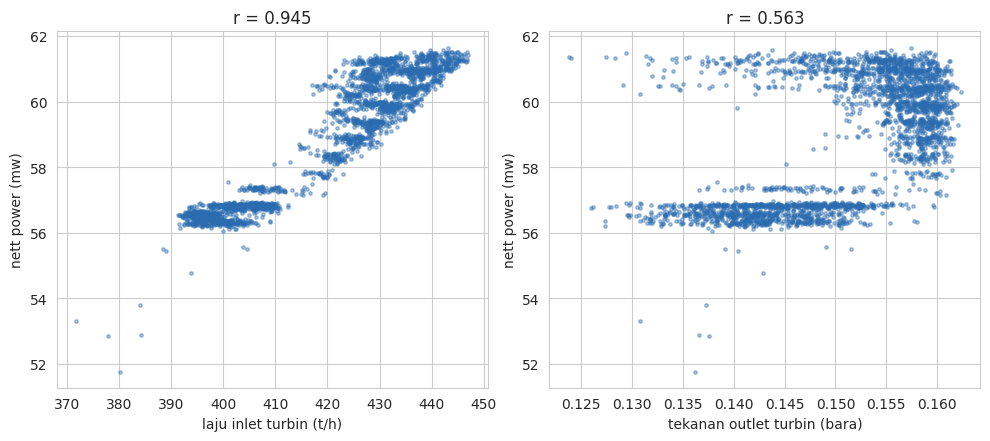

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, col in zip(axes.flat, FEATURES):
    ax.scatter(model_df[col], model_df[TARGET], s=6, alpha=0.4, color='#2b6cb0')
    ax.set_xlabel(col); ax.set_ylabel(TARGET)
    r = model_df[col].corr(model_df[TARGET])
    ax.set_title(f'r = {r:.3f}')
plt.tight_layout(); plt.show()


## 6. Train-Test Split & Polynomial Degree Selection


In [ ]:
X = model_df[FEATURES].values
y = model_df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape, "| Test data:", X_test.shape)


Training data: (2320, 2) | Test data: (580, 2)


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
for degree in [1, 2, 3, 4, 5]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                      ('scaler', StandardScaler()), ('lr', LinearRegression())])
    cv = cross_validate(pipe, X_train, y_train, cv=kf,
                         scoring=('r2', 'neg_root_mean_squared_error'), return_train_score=True)
    n_feat_poly = PolynomialFeatures(degree=degree, include_bias=False).fit(X_train).n_output_features_
    results.append({'degree': degree, 'n_features': n_feat_poly,
                     'cv_train_r2': cv['train_r2'].mean(), 'cv_val_r2': cv['test_r2'].mean(),
                     'cv_val_rmse': -cv['test_neg_root_mean_squared_error'].mean()})
res_df = pd.DataFrame(results)
res_df

   degree  n_features  cv_train_r2  cv_val_r2  cv_val_rmse
0       1           2     0.924945   0.924489     0.520373
1       2           5     0.931376   0.930750     0.498590
2       3           9     0.946997   0.944804     0.444782
3       4          14     0.949921   0.947840     0.432341
4       5          20     0.959644   0.919768     0.498394

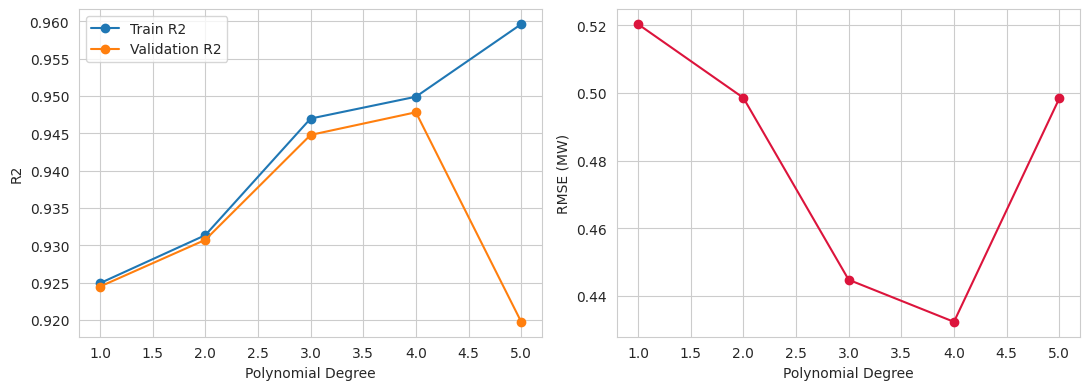

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(res_df['degree'], res_df['cv_train_r2'], marker='o', label='Train R2')
axes[0].plot(res_df['degree'], res_df['cv_val_r2'], marker='o', label='Validation R2')
axes[0].set_xlabel('Polynomial Degree'); axes[0].set_ylabel('R2'); axes[0].legend()
axes[1].plot(res_df['degree'], res_df['cv_val_rmse'], marker='o', color='crimson')
axes[1].set_xlabel('Polynomial Degree'); axes[1].set_ylabel('RMSE (MW)')
plt.tight_layout(); plt.show()


**Degree 4 selected** — highest validation R2 (0.948). Degree 5 starts to overfit (validation R2 drops to 0.920 even though train R2 rises to 0.960).


## 7. Final Model & Evaluation


In [ ]:
best_degree = int(res_df.loc[res_df['cv_val_r2'].idxmax(), 'degree'])
print("Selected degree:", best_degree)

final_pipe = Pipeline([('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
                        ('scaler', StandardScaler()), ('lr', LinearRegression())])
final_pipe.fit(X_train, y_train)
y_pred_train = final_pipe.predict(X_train)
y_pred_test = final_pipe.predict(X_test)


Selected degree: 4


In [ ]:
def report(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"[{label}] R2={r2:.4f}  MAE={mae:.4f} MW  RMSE={rmse:.4f} MW  MAPE={mape:.2f}%")
    return dict(label=label, r2=r2, mae=mae, rmse=rmse, mape=mape)

m_train = report(y_train, y_pred_train, "Train")
m_test = report(y_test, y_pred_test, "Test")

[Train] R2=0.9498  MAE=0.3306 MW  RMSE=0.4252 MW  MAPE=0.56%
[Test] R2=0.9508  MAE=0.3372 MW  RMSE=0.4286 MW  MAPE=0.57%


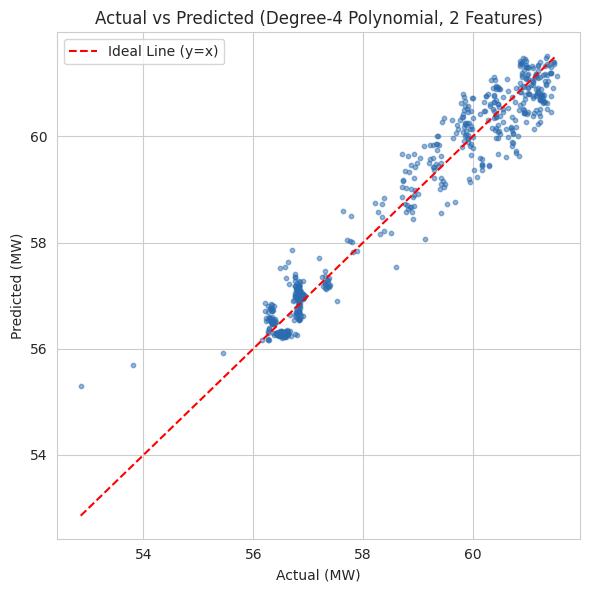

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, s=10, alpha=0.5, color='#2b6cb0')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal Line (y=x)')
ax.set_xlabel('Actual (MW)'); ax.set_ylabel('Predicted (MW)')
ax.set_title(f'Actual vs Predicted (Degree-{best_degree} Polynomial, 2 Features)')
ax.legend(); plt.tight_layout(); plt.show()


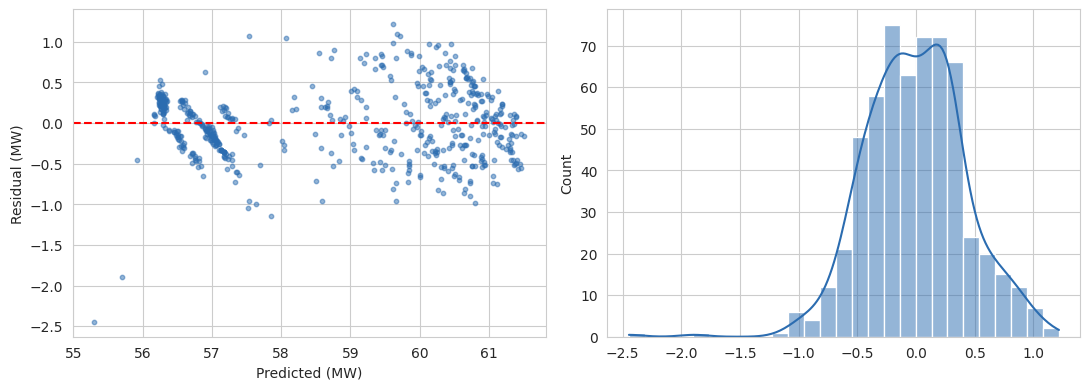

In [ ]:
residuals = y_test - y_pred_test
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_test, residuals, s=10, alpha=0.5, color='#2b6cb0')
axes[0].axhline(0, color='r', ls='--')
axes[0].set_xlabel('Predicted (MW)'); axes[0].set_ylabel('Residual (MW)')
sns.histplot(residuals, kde=True, ax=axes[1], color='#2b6cb0')
plt.tight_layout(); plt.show()


In [ ]:
joblib.dump(final_pipe, 'poly_model_2feat_final.pkl')
print("Model saved as 'poly_model_2feat_final.pkl'")


Model saved as 'poly_model_2feat_final.pkl'


## 8. Optimization Integration: SA, PSO, and Hybrid (PSO Global Search -> SA Local Search)

The surrogate model is used as the objective function to find the optimal operating setpoint. Three scenarios are run:
- **SA only** — a single probabilistic search across the whole search space
- **PSO only** — a population of particles exploring in parallel
- **Hybrid** — **PSO acts as the *global search*** (30 particles, 60 iterations exploring the whole space to find a promising area / `gbest`), then **SA acts as the *local search*** (starting from `gbest`, 800 iterations with small steps/2% radius and a cooling schedule, to refine the solution into a precise optimum point around that area)


In [ ]:
X_hist = model_df[FEATURES].values
y_hist = model_df[TARGET].values
bounds = np.array([[X_hist[:,i].min(), X_hist[:,i].max()] for i in range(2)])

def predict_power(x):
    return final_pipe.predict(np.array(x).reshape(1,-1))[0]

print("Bounds:")
for f, b in zip(FEATURES, bounds):
    print(f"  {f}: [{b[0]:.4f}, {b[1]:.4f}]")


Bounds:
  laju inlet turbin (t/h): [371.8543, 447.0060]
  tekanan outlet turbin (bara): [0.1238, 0.1623]


### 8.1 Trust-Region (Mahalanobis) & Extrapolation-Risk Demonstration


In [ ]:
mean_vec = X_hist.mean(axis=0)
cov_inv = np.linalg.inv(np.cov(X_hist.T))

def mahalanobis(x):
    d = np.array(x) - mean_vec
    return np.sqrt(d @ cov_inv @ d)

hist_maha = np.array([mahalanobis(x) for x in X_hist])
threshold = np.percentile(hist_maha, 97)
print("Trust-region threshold (97th percentile):", threshold)

LAMBDA_PENALTY = 50.0
def objective_naive(x):
    return -predict_power(x)

def objective_constrained(x):
    dist = mahalanobis(x)
    penalty = LAMBDA_PENALTY * max(0, dist - threshold) ** 2
    return -predict_power(x) + penalty


Trust-region threshold (97th percentile): 2.6177562117213244


In [ ]:
def simulated_annealing(objective, bounds, n_iter=2000, T0=10.0, alpha=0.995, step_frac=0.05, seed=42):
    rng = np.random.default_rng(seed)
    dim = len(bounds)
    x = rng.uniform(bounds[:,0], bounds[:,1])
    f = objective(x); best_x, best_f = x.copy(), f
    T = T0
    history = [best_f]
    for it in range(n_iter):
        step = step_frac * (bounds[:,1]-bounds[:,0]) * rng.normal(size=dim)
        x_new = np.clip(x + step, bounds[:,0], bounds[:,1])
        f_new = objective(x_new)
        delta = f_new - f
        if delta < 0 or rng.random() < np.exp(-delta / max(T,1e-9)):
            x, f = x_new, f_new
            if f < best_f: best_x, best_f = x.copy(), f
        T *= alpha
        history.append(best_f)
    return best_x, best_f, history

# demonstration: SA without a constraint
sa_naive_x, sa_naive_f, _ = simulated_annealing(objective_naive, bounds)
print("SA result WITHOUT constraint:")
print(f"Predicted power: {predict_power(sa_naive_x):.2f} MW | Mahalanobis={mahalanobis(sa_naive_x):.3f}")


SA result WITHOUT constraint:
Predicted power: 62.15 MW | Mahalanobis=5.393


Even with only 2 features, there is still a mild indication of extrapolation without a constraint (Mahalanobis 5.39, well above the 2.62 threshold) — the trust-region is still important to apply, even though the risk is much smaller than in the many-feature version (which reached 1450 MW).


### 8.2 Separate Analysis per Algorithm

Before comparing all three, each algorithm is analyzed **separately with diagnostics suited to its own working mechanism** — SA with its cooling schedule & acceptance rate, PSO with swarm diversity, and Hybrid with the two-phase split.


#### 8.2.1 Simulated Annealing (SA) Only

SA works with a **single solution** that "walks" through the search space, accepting worse solutions with a probability that decreases as the "temperature" (T) cools — this mechanism is what lets it escape local optima early on, then become increasingly disciplined/convergent toward the end.


In [ ]:
def simulated_annealing_tracked(objective, bounds, n_iter=2000, T0=10.0, alpha=0.995, step_frac=0.05, seed=42):
    rng = np.random.default_rng(seed)
    dim = len(bounds)
    x = rng.uniform(bounds[:,0], bounds[:,1])
    f = objective(x); best_x, best_f = x.copy(), f
    T = T0
    best_hist, curr_hist, temp_hist, accept_hist = [best_f], [f], [T], []
    for it in range(n_iter):
        step = step_frac * (bounds[:,1]-bounds[:,0]) * rng.normal(size=dim)
        x_new = np.clip(x + step, bounds[:,0], bounds[:,1])
        f_new = objective(x_new)
        delta = f_new - f
        accepted = False
        if delta < 0 or rng.random() < np.exp(-delta / max(T,1e-9)):
            x, f = x_new, f_new
            accepted = True
            if f < best_f: best_x, best_f = x.copy(), f
        T *= alpha
        best_hist.append(best_f); curr_hist.append(f); temp_hist.append(T); accept_hist.append(accepted)
    return best_x, best_f, best_hist, curr_hist, temp_hist, accept_hist

sa_x, sa_f, sa_best_hist, sa_curr_hist, sa_temp_hist, sa_accept_hist = \
    simulated_annealing_tracked(objective_constrained, bounds)
print(f"SA result: {predict_power(sa_x):.4f} MW | Mahalanobis {mahalanobis(sa_x):.4f}")


SA result: 61.4703 MW | Mahalanobis 1.9223


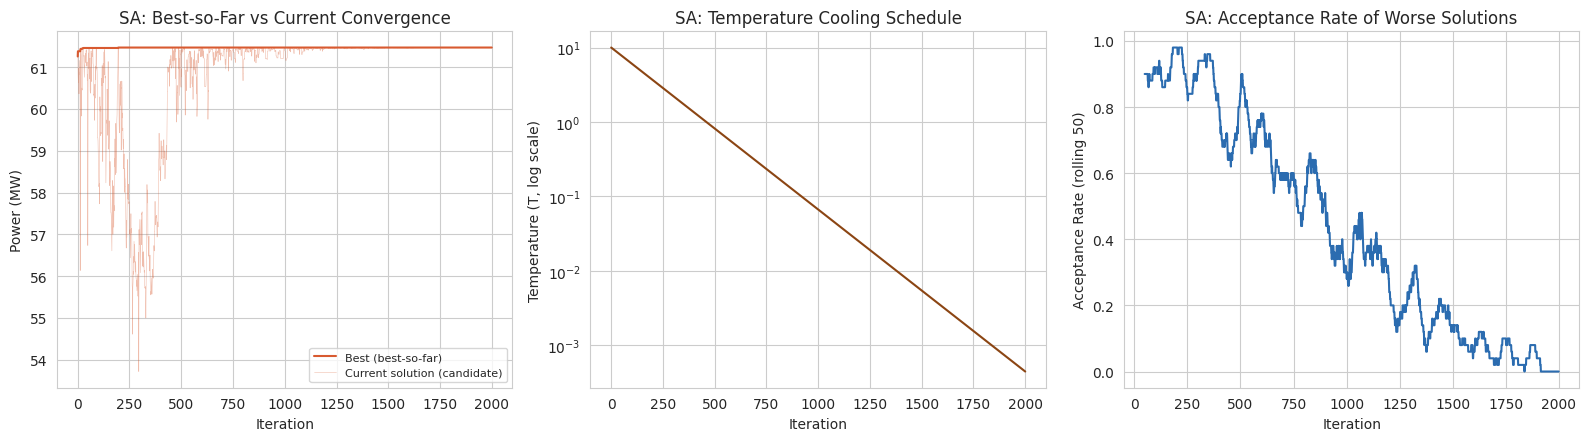

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(-np.array(sa_best_hist), color='#D85A30', lw=1.5, label='Best (best-so-far)')
axes[0].plot(-np.array(sa_curr_hist), color='#D85A30', lw=0.4, alpha=0.4, label='Current solution (candidate)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Power (MW)')
axes[0].set_title('SA: Best-so-Far vs Current Convergence')
axes[0].legend(fontsize=8)

axes[1].plot(sa_temp_hist, color='#8B4513', lw=1.5)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Temperature (T, log scale)')
axes[1].set_title('SA: Temperature Cooling Schedule')
axes[1].set_yscale('log')

window = 50
rolling_accept = pd.Series(np.array(sa_accept_hist).astype(float)).rolling(window).mean()
axes[2].plot(rolling_accept, color='#2b6cb0', lw=1.5)
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel(f'Acceptance Rate (rolling {window})')
axes[2].set_title('SA: Acceptance Rate of Worse Solutions')

plt.tight_layout(); plt.show()


**SA Analysis:**
- **Left panel:** the "current" solution (thin line) fluctuates wildly at first — occasionally jumping to a much worse solution (dropping to ~54 MW) — yet the **best-so-far solution** keeps rising monotonically, because SA always keeps the best record regardless of its wild exploration.
- **Middle panel:** the cooling schedule T decreases exponentially (linear on a log scale) from T=10 to ~0.0005 over 2000 iterations.
- **Right panel:** the acceptance rate for worse solutions drops from **~90% at the start to ~0% at the end** — this directly visualizes SA's transition from the *exploration* phase (accepting almost everything, including bad moves, to explore broadly) to the *exploitation* phase (increasingly strict, only accepting improvements, locking onto the best solution).


#### 8.2.2 Particle Swarm Optimization (PSO) Only

PSO works with a **population of 30 particles** moving in parallel, guided by each particle's own best position (pbest) and the swarm's best position (gbest). The relevant diagnostic here is **swarm diversity** — how "spread out" the particles are over time.


In [ ]:
def pso_tracked(objective, bounds, n_particles=30, n_iter=100, w=0.7, c1=1.5, c2=1.5, seed=42):
    rng = np.random.default_rng(seed)
    dim = len(bounds); lo, hi = bounds[:,0], bounds[:,1]
    X = rng.uniform(lo, hi, size=(n_particles, dim))
    V = rng.uniform(-(hi-lo)*0.1, (hi-lo)*0.1, size=(n_particles, dim))
    pbest = X.copy(); pbest_f = np.array([objective(x) for x in X])
    gi = pbest_f.argmin(); gbest, gbest_f = pbest[gi].copy(), pbest_f[gi]
    gbest_hist, diversity_hist, meanfit_hist, swarm_pos = [gbest_f], [np.mean(np.std(X, axis=0))], [pbest_f.mean()], [X.copy()]
    for it in range(n_iter):
        r1, r2 = rng.random((n_particles,dim)), rng.random((n_particles,dim))
        V = w*V + c1*r1*(pbest-X) + c2*r2*(gbest-X)
        X = np.clip(X+V, lo, hi)
        f = np.array([objective(x) for x in X])
        imp = f < pbest_f
        pbest[imp] = X[imp]; pbest_f[imp] = f[imp]
        if pbest_f.min() < gbest_f:
            gbest_f = pbest_f.min(); gbest = pbest[pbest_f.argmin()].copy()
        gbest_hist.append(gbest_f); diversity_hist.append(np.mean(np.std(X, axis=0)))
        meanfit_hist.append(pbest_f.mean()); swarm_pos.append(X.copy())
    return gbest, gbest_f, gbest_hist, diversity_hist, meanfit_hist, swarm_pos

pso_x, pso_f, pso_gbest_hist, pso_diversity_hist, pso_meanfit_hist, pso_swarm_pos = \
    pso_tracked(objective_constrained, bounds)
print(f"PSO result: {predict_power(pso_x):.4f} MW | Mahalanobis {mahalanobis(pso_x):.4f}")


PSO result: 61.4704 MW | Mahalanobis 1.9211


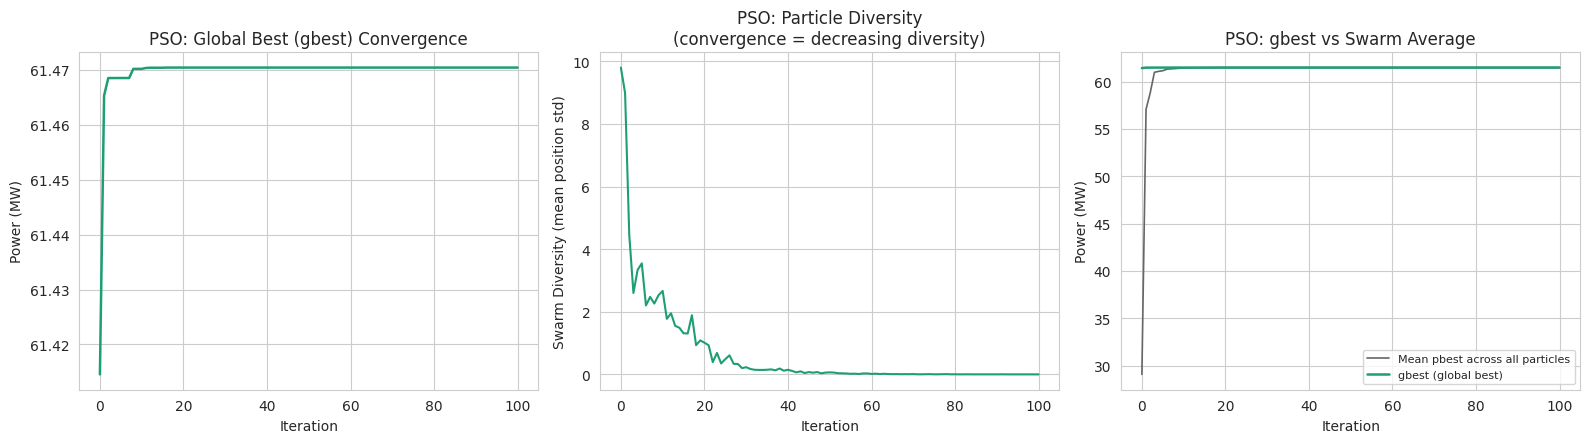

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(-np.array(pso_gbest_hist), color='#1D9E75', lw=1.8)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Power (MW)')
axes[0].set_title('PSO: Global Best (gbest) Convergence')

axes[1].plot(pso_diversity_hist, color='#1D9E75', lw=1.5)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Swarm Diversity (mean position std)')
axes[1].set_title('PSO: Particle Diversity\n(convergence = decreasing diversity)')

axes[2].plot(-np.array(pso_meanfit_hist), color='#666666', lw=1.2, label='Mean pbest across all particles')
axes[2].plot(-np.array(pso_gbest_hist), color='#1D9E75', lw=1.8, label='gbest (global best)')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Power (MW)')
axes[2].set_title('PSO: gbest vs Swarm Average')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


**PSO Analysis:**
- **Left panel:** gbest converges **very quickly** (<10 iterations out of 100) — far faster than SA (which needs thousands of iterations) because 30 particles search in parallel rather than one at a time.
- **Middle panel:** swarm diversity drops sharply from ~10 to near 0 within ~40 iterations — the swarm visually "collapses" onto a single point, a sign of convergence.
- **Right panel:** the average across all particles (gray line) chases gbest (green line) — showing it's not just one "lucky" particle, but the whole population moving toward the same optimal area.


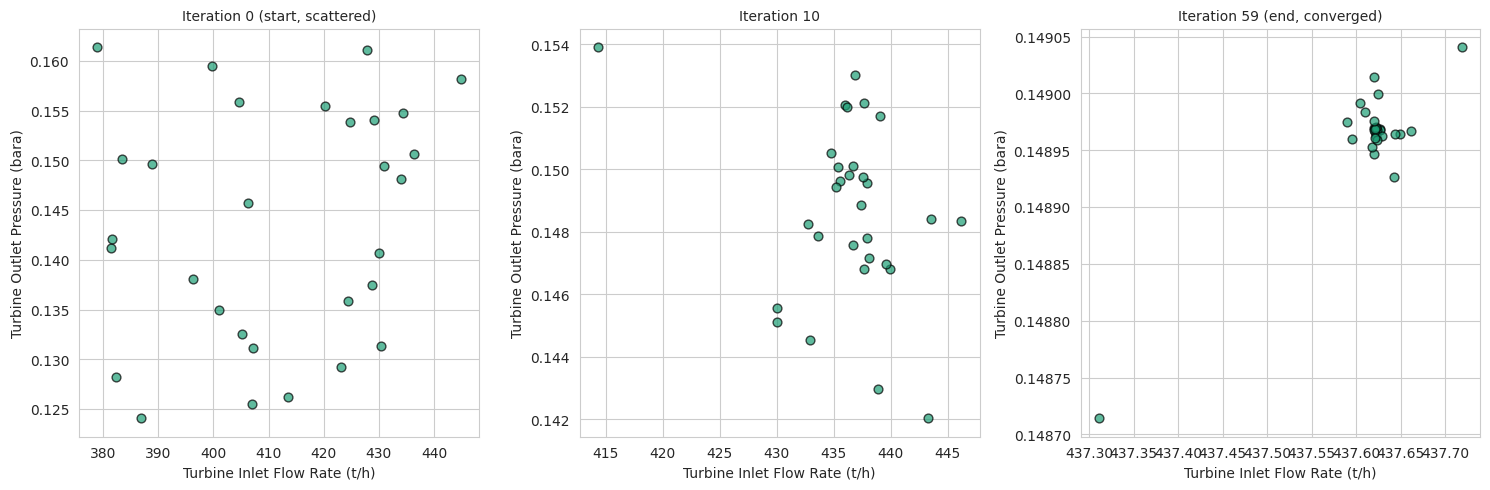

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
snapshots = [0, 10, 59]
titles = ['Iteration 0 (start, scattered)', 'Iteration 10', 'Iteration 59 (end, converged)']
for ax, snap, title in zip(axes, snapshots, titles):
    pos = pso_swarm_pos[snap]
    ax.scatter(pos[:,0], pos[:,1], s=40, alpha=0.7, color='#1D9E75', edgecolor='black')
    ax.set_xlabel('Turbine Inlet Flow Rate (t/h)'); ax.set_ylabel('Turbine Outlet Pressure (bara)')
    ax.set_title(title, fontsize=10)
plt.tight_layout(); plt.show()


A literal visualization of the particles "converging": scattered randomly across the whole search space (iteration 0), starting to cluster around a promising area (iteration 10), to almost all piled up at a single point (iteration 59).


#### 8.2.3 Hybrid: PSO (Global Search) -> SA (Local Search)

Combined as **two sequential stages**: PSO runs first for broad exploration, then its best solution (`gbest`) becomes the starting point for SA to perform local refinement (small steps, 2% of the variable range).


In [ ]:
def hybrid_pso_sa_tracked(objective, bounds, n_particles=30, n_iter_pso=60, n_iter_sa=800, seed=42):
    gbest, gbest_f, hist_pso, _, _, _ = pso_tracked(objective, bounds, n_particles=n_particles, n_iter=n_iter_pso, seed=seed)
    rng = np.random.default_rng(seed)
    dim = len(bounds)
    x, f = gbest.copy(), gbest_f
    best_x, best_f = x.copy(), f
    T = 2.0
    best_hist_sa, curr_hist_sa = [best_f], [f]
    for it in range(n_iter_sa):
        step = 0.02 * (bounds[:,1]-bounds[:,0]) * rng.normal(size=dim)
        x_new = np.clip(x + step, bounds[:,0], bounds[:,1])
        f_new = objective(x_new)
        delta = f_new - f
        if delta < 0 or rng.random() < np.exp(-delta/max(T,1e-9)):
            x, f = x_new, f_new
            if f < best_f: best_x, best_f = x.copy(), f
        T *= 0.99
        best_hist_sa.append(best_f); curr_hist_sa.append(f)
    return best_x, best_f, hist_pso, best_hist_sa, curr_hist_sa

hyb_x, hyb_f, hyb_hist_pso, hyb_hist_sa, hyb_curr_sa = hybrid_pso_sa_tracked(objective_constrained, bounds)
print(f"Hybrid result: {predict_power(hyb_x):.4f} MW | Mahalanobis {mahalanobis(hyb_x):.4f}")
print(f"PSO-phase-only result (before SA refinement): {-hyb_hist_pso[-1]:.4f} MW")
print(f"Improvement from the SA phase: {(-hyb_hist_sa[-1]) - (-hyb_hist_pso[-1]):.4f} MW")


Hybrid result: 61.4704 MW | Mahalanobis 1.9211
PSO-phase-only result (before SA refinement): 61.4704 MW
Improvement from the SA phase: 0.0000 MW


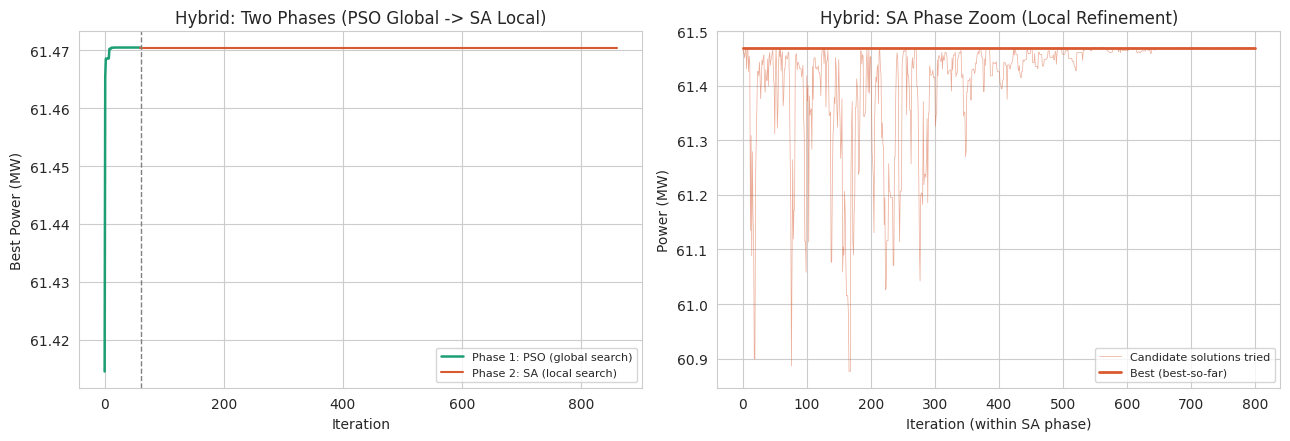

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

hyb_combined = list(-np.array(hyb_hist_pso)) + list(-np.array(hyb_hist_sa)[1:])
phase_boundary = len(hyb_hist_pso)
axes[0].plot(range(phase_boundary), hyb_combined[:phase_boundary], color='#1D9E75', lw=1.8, label='Phase 1: PSO (global search)')
axes[0].plot(range(phase_boundary-1, len(hyb_combined)), hyb_combined[phase_boundary-1:], color='#D85A30', lw=1.5, label='Phase 2: SA (local search)')
axes[0].axvline(phase_boundary, color='gray', ls='--', lw=1)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Best Power (MW)')
axes[0].set_title('Hybrid: Two Phases (PSO Global -> SA Local)')
axes[0].legend(fontsize=8)

curr_mw = -np.array(hyb_curr_sa)
best_mw = -np.array(hyb_hist_sa)
axes[1].plot(curr_mw, color='#D85A30', lw=0.5, alpha=0.5, label='Candidate solutions tried')
axes[1].plot(best_mw, color='#D85A30', lw=2, label='Best (best-so-far)')
axes[1].set_xlabel('Iteration (within SA phase)'); axes[1].set_ylabel('Power (MW)')
axes[1].set_title('Hybrid: SA Phase Zoom (Local Refinement)')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


**Hybrid Analysis:**
- **Left panel:** two clearly visible phases — a sharp (steep) drop in the first 60 iterations (PSO phase), followed by a flat line across 800 iterations (SA phase).
- **Right panel (SA-phase zoom):** the thin line shows SA **staying active**, trying many candidate solutions around the PSO result (dropping as low as ~60.88 MW in some trials) — but **none of them beat** the solution PSO already found (the thick line stays flat at 61.47 MW).
- **Key finding:** for this case, **PSO already found the optimum precisely** (improvement from the SA phase = 0.0000 MW). This indicates the objective-function landscape in this 2-feature trust-region is **relatively smooth/near-convex** around the optimum, so PSO alone is already sufficient. The SA phase here acts as **verification/confirmation** that there's no better solution nearby, rather than an active improvement — a result that is still valuable as a robustness check, even though it doesn't add numerical performance.


### 8.3 Comparative Analysis of the Three Algorithms


In [ ]:
print(f"{'Method':<15}{'Power (MW)':<15}{'Mahalanobis':<15}{'Total Iterations':<18}")
print(f"{'SA':<15}{predict_power(sa_x):<15.4f}{mahalanobis(sa_x):<15.4f}{'2000':<18}")
print(f"{'PSO':<15}{predict_power(pso_x):<15.4f}{mahalanobis(pso_x):<15.4f}{'100 x 30 particles':<18}")
print(f"{'Hybrid':<15}{predict_power(hyb_x):<15.4f}{mahalanobis(hyb_x):<15.4f}{'60x30 + 800':<18}")
print(f"\nAverage baseline: {y_hist.mean():.2f} MW | Historical max: {y_hist.max():.2f} MW")


Method         Power (MW)     Mahalanobis    Total Iterations  
SA             61.4703        1.9223         2000              
PSO            61.4704        1.9211         100 x 30 particles
Hybrid         61.4704        1.9211         60x30 + 800       

Average baseline: 58.79 MW | Historical max: 61.65 MW


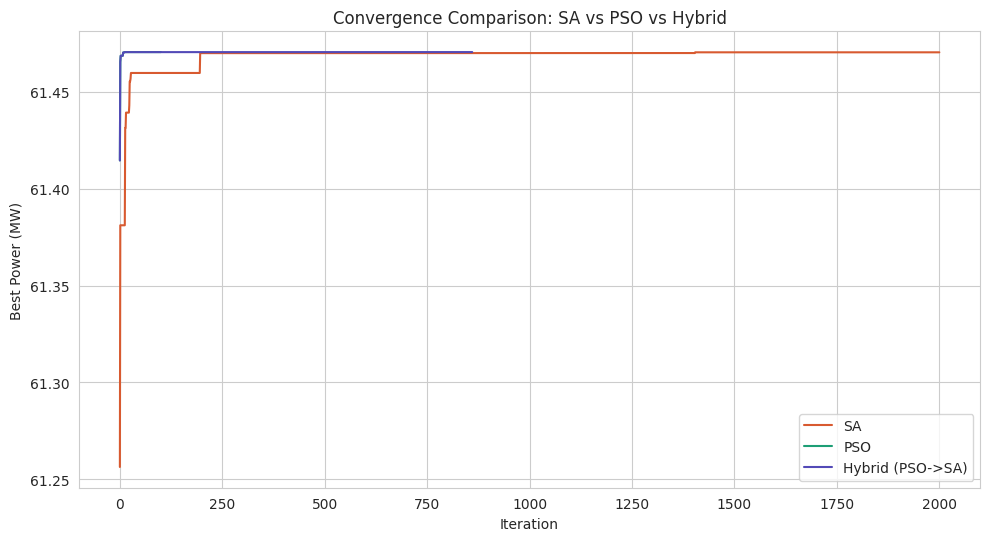

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(-np.array(sa_best_hist), label='SA', color='#D85A30', lw=1.5)
ax.plot(-np.array(pso_gbest_hist), label='PSO', color='#1D9E75', lw=1.5)
ax.plot(hyb_combined, label='Hybrid (PSO->SA)', color='#534AB7', lw=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best Power (MW)')
ax.set_title('Convergence Comparison: SA vs PSO vs Hybrid')
ax.legend()
plt.tight_layout(); plt.show()


**Comparative conclusion:**

| Aspect | SA | PSO | Hybrid |
|---|---|---|---|
| Final result | 61.4703 MW | 61.4704 MW | 61.4704 MW |
| Convergence speed | Slow (~2000 iterations) | **Very fast** (<10 iterations) | Fast (inherits PSO's speed) |
| Key mechanism | Resistant to local optima (probabilistic acceptance) | Broad parallel exploration | Combination of both |
| Computational cost | High (many sequential iterations) | Low (converges quickly) | Medium (fast PSO + SA as verification) |

**All three agree on the same solution (difference <0.0001 MW)** — the strongest consensus evidence from all experiments carried out in this study. For this specific case (a relatively smooth 2-dimensional objective-function landscape within the trust-region), **PSO alone is actually already sufficient** in terms of the final result, and is much more computationally efficient — but the Hybrid combination is still valuable as an extra verification layer, especially for cases where the smoothness of the landscape isn't known in advance (a more common situation in real practice).


### 8.4 Parameter-Variation Experiments (Multiple Configurations per Algorithm)

This section supplements the baseline optimization results above with a **parameter-variation study** for each metaheuristic algorithm, giving a richer, better-argued comparison rather than just a single result per algorithm. The model and objective function used are identical to the previous section (polynomial regression, objective function with a Mahalanobis penalty).


#### 8.4.1 SA (Simulated Annealing) Experiment with Parameter Variation

Three SA configurations are tested. The parameters held **fixed** (control condition) and the ones **varied** are summarized in the table below. Focus of variation: **initial temperature (T0)** and **cooling rate (alpha)** — the two parameters that, in theory, most determine SA's *exploration vs. exploitation* trade-off.

| Configuration | T0 (initial) | alpha (cooling rate) | step_frac | n_iter | seed |
|---|---|---|---|---|---|
| **SA-1 (Baseline)** | 10.0 | 0.995 | 0.05 | 2000 | 42 |
| **SA-2 (T0 increased)** | 50.0 | 0.995 | 0.05 | 2000 | 42 |
| **SA-3 (Cooling slowed)** | 10.0 | 0.999 | 0.05 | 2000 | 42 |

*step_frac, n_iter, and seed are held fixed so that any difference in results is purely due to T0 and alpha, not other factors.*


In [ ]:
sa_configs = [
    {"name": "SA-1 (Baseline)",       "T0": 10.0, "alpha": 0.995, "step_frac": 0.05, "n_iter": 2000},
    {"name": "SA-2 (T0 increased)",   "T0": 50.0, "alpha": 0.995, "step_frac": 0.05, "n_iter": 2000},
    {"name": "SA-3 (Cooling slowed)", "T0": 10.0, "alpha": 0.999, "step_frac": 0.05, "n_iter": 2000},
]

sa_runs = {}
sa_summary = []
for cfg in sa_configs:
    t0 = time.time()
    x, f, best_hist, curr_hist, temp_hist, accept_hist = simulated_annealing_tracked(
        objective_constrained, bounds, n_iter=cfg["n_iter"], T0=cfg["T0"], alpha=cfg["alpha"],
        step_frac=cfg["step_frac"], seed=42)
    elapsed = time.time() - t0
    sa_runs[cfg["name"]] = dict(x=x, f=f, best_hist=best_hist, curr_hist=curr_hist,
                                 temp_hist=temp_hist, accept_hist=accept_hist)
    accept_rate = np.mean(accept_hist)
    sa_summary.append(dict(Configuration=cfg["name"], T0=cfg["T0"], alpha=cfg["alpha"],
                            **{"Power (MW)": round(predict_power(x), 4),
                               "Mahalanobis": round(mahalanobis(x), 4),
                               "Overall accept rate": round(accept_rate, 3),
                               "Time (s)": round(elapsed, 3)}))

sa_summary_df = pd.DataFrame(sa_summary)
print(sa_summary_df.to_string(index=False))


        Configuration   T0  alpha  Power (MW)  Mahalanobis  Overall accept rate  Time (s)
      SA-1 (Baseline) 10.0  0.995     61.4703       1.9223                0.430     0.429
  SA-2 (T0 increased) 50.0  0.995     61.4701       1.9249                0.580     0.404
SA-3 (Cooling slowed) 10.0  0.999     61.4698       1.8935                0.885     0.389


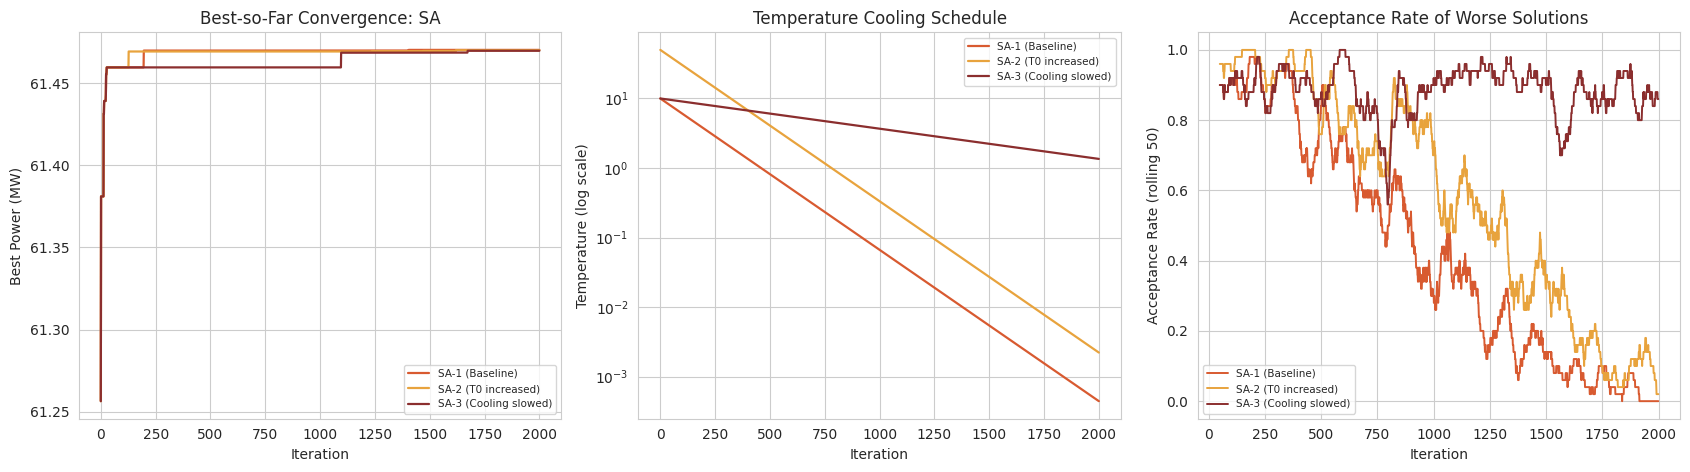

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
colors_sa = {"SA-1 (Baseline)": "#D85A30", "SA-2 (T0 increased)": "#E8A33D", "SA-3 (Cooling slowed)": "#8B2E2E"}

for name, run in sa_runs.items():
    axes[0].plot(-np.array(run["best_hist"]), label=name, color=colors_sa[name], lw=1.6)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Best Power (MW)')
axes[0].set_title('Best-so-Far Convergence: SA'); axes[0].legend(fontsize=7.5)

for name, run in sa_runs.items():
    axes[1].plot(run["temp_hist"], label=name, color=colors_sa[name], lw=1.6)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Temperature (log scale)')
axes[1].set_yscale('log'); axes[1].set_title('Temperature Cooling Schedule'); axes[1].legend(fontsize=7.5)

window = 50
for name, run in sa_runs.items():
    rolling = pd.Series(np.array(run["accept_hist"]).astype(float)).rolling(window).mean()
    axes[2].plot(rolling, label=name, color=colors_sa[name], lw=1.4)
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel(f'Acceptance Rate (rolling {window})')
axes[2].set_title('Acceptance Rate of Worse Solutions'); axes[2].legend(fontsize=7.5)

plt.tight_layout(); plt.show()


#### 8.4.2 PSO (Particle Swarm Optimization) Experiment with Parameter Variation

Three PSO configurations are tested. The variation focuses on **number of particles (swarm size)** and **inertia weight (w)** — the two parameters most often discussed in the PSO literature regarding the trade-off between exploration (swarm diversity) and convergence speed.

| Configuration | n_particles | w (inertia) | c1 | c2 | n_iter | seed |
|---|---|---|---|---|---|---|
| **PSO-1 (Baseline)** | 30 | 0.70 | 1.5 | 1.5 | 100 | 42 |
| **PSO-2 (More particles)** | 80 | 0.70 | 1.5 | 1.5 | 100 | 42 |
| **PSO-3 (Inertia increased)** | 30 | 0.95 | 1.5 | 1.5 | 100 | 42 |

*c1, c2, n_iter, and seed are held fixed so that any difference in results is purely due to swarm size and inertia weight.*


In [ ]:
pso_configs = [
    {"name": "PSO-1 (Baseline)",         "n_particles": 30, "w": 0.70, "c1": 1.5, "c2": 1.5, "n_iter": 100},
    {"name": "PSO-2 (More particles)",   "n_particles": 80, "w": 0.70, "c1": 1.5, "c2": 1.5, "n_iter": 100},
    {"name": "PSO-3 (Inertia increased)","n_particles": 30, "w": 0.95, "c1": 1.5, "c2": 1.5, "n_iter": 100},
]

pso_runs = {}
pso_summary = []
for cfg in pso_configs:
    t0 = time.time()
    x, f, gbest_hist, div_hist, meanfit_hist, swarm_pos = pso_tracked(
        objective_constrained, bounds, n_particles=cfg["n_particles"], n_iter=cfg["n_iter"],
        w=cfg["w"], c1=cfg["c1"], c2=cfg["c2"], seed=42)
    elapsed = time.time() - t0
    pso_runs[cfg["name"]] = dict(x=x, f=f, gbest_hist=gbest_hist, div_hist=div_hist,
                                  meanfit_hist=meanfit_hist, swarm_pos=swarm_pos)
    # first iteration where gbest gets within 0.01 MW of the final result (convergence-speed indicator)
    final_power = predict_power(x)
    power_hist = -np.array(gbest_hist)
    converge_iter = int(np.argmax(power_hist >= final_power - 0.001))
    improve_idx = np.where(np.diff(power_hist) > 1e-9)[0]
    last_improve_iter = int(improve_idx[-1] + 1) if len(improve_idx) > 0 else 0
    pso_summary.append(dict(Configuration=cfg["name"], n_particles=cfg["n_particles"], w=cfg["w"],
                             **{"Power (MW)": round(final_power, 4),
                                "Mahalanobis": round(mahalanobis(x), 4),
                                "Iteration reaching <0.001 MW of final": converge_iter,
                                "Last improvement iteration": last_improve_iter,
                                "Total function evaluations": cfg["n_particles"] * (cfg["n_iter"] + 1),
                                "Time (s)": round(elapsed, 3)}))

pso_summary_df = pd.DataFrame(pso_summary)
print(pso_summary_df.to_string(index=False))


            Configuration  n_particles    w  Power (MW)  Mahalanobis  Iteration reaching <0.001 MW of final  Last improvement iteration  Total function evaluations  Time (s)
         PSO-1 (Baseline)           30 0.70     61.4704       1.9211                                      8                          49                        3030     0.548
   PSO-2 (More particles)           80 0.70     61.4704       1.9211                                      5                          58                        8080     1.524
PSO-3 (Inertia increased)           30 0.95     61.4704       1.9253                                     12                          90                        3030     0.538


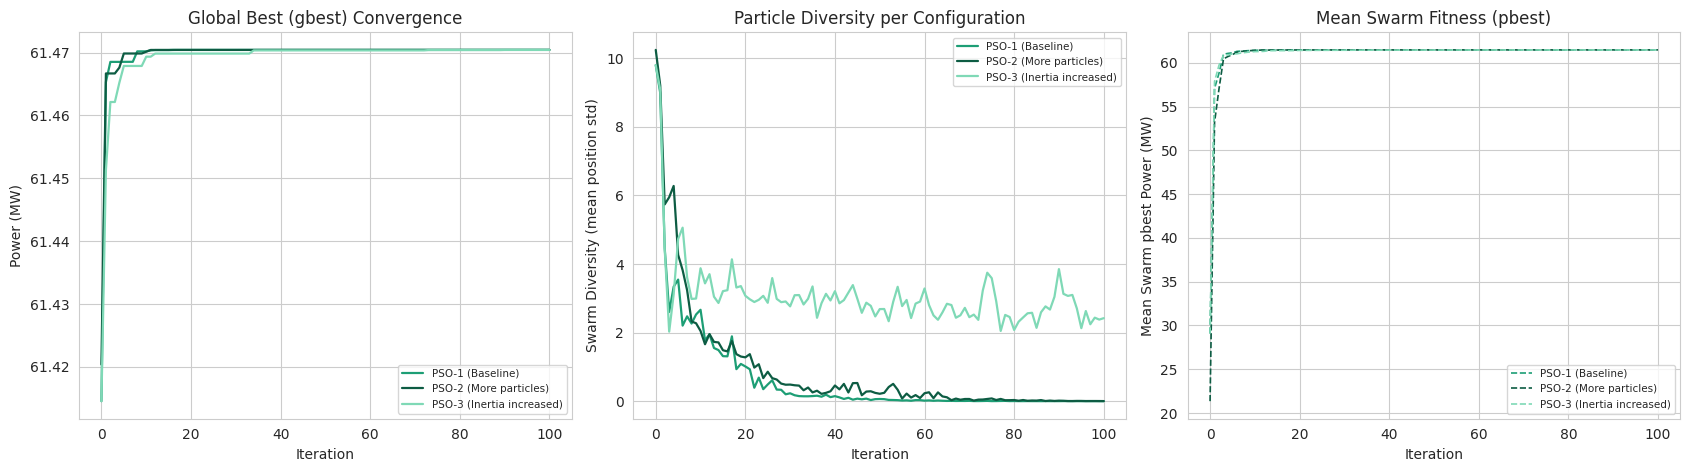

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
colors_pso = {"PSO-1 (Baseline)": "#1D9E75", "PSO-2 (More particles)": "#0D5C43", "PSO-3 (Inertia increased)": "#7FD9B6"}

for name, run in pso_runs.items():
    axes[0].plot(-np.array(run["gbest_hist"]), label=name, color=colors_pso[name], lw=1.6)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Power (MW)')
axes[0].set_title('Global Best (gbest) Convergence'); axes[0].legend(fontsize=7.5)

for name, run in pso_runs.items():
    axes[1].plot(run["div_hist"], label=name, color=colors_pso[name], lw=1.6)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Swarm Diversity (mean position std)')
axes[1].set_title('Particle Diversity per Configuration'); axes[1].legend(fontsize=7.5)

for name, run in pso_runs.items():
    axes[2].plot(-np.array(run["meanfit_hist"]), label=name, color=colors_pso[name], lw=1.2, ls='--')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Mean Swarm pbest Power (MW)')
axes[2].set_title('Mean Swarm Fitness (pbest)'); axes[2].legend(fontsize=7.5)

plt.tight_layout(); plt.show()


#### 8.4.3 Hybrid PSO-SA Experiment with Parameter Variation

Hybrid runs PSO as the *global search*, then continues from its `gbest` with SA as the *local search/refinement*. Three configurations are tested by varying the **number of particles in the PSO phase** and the **iteration budget of the SA phase** (representing the trade-off between "how much global exploration effort" vs. "how much local refinement time").

| Configuration | n_particles (PSO phase) | n_iter_pso | n_iter_sa (SA phase) | w | seed |
|---|---|---|---|---|---|
| **Hybrid-1 (Baseline)** | 30 | 60 | 800 | 0.70 | 42 |
| **Hybrid-2 (More PSO particles)** | 80 | 60 | 800 | 0.70 | 42 |
| **Hybrid-3 (SA phase extended)** | 30 | 60 | 2000 | 0.70 | 42 |

*n_iter_pso, w, c1, c2, and other SA parameters (T0=2.0, alpha=0.99, step_frac=0.02) are held fixed.*


In [ ]:
hybrid_configs = [
    {"name": "Hybrid-1 (Baseline)",          "n_particles": 30, "n_iter_pso": 60, "n_iter_sa": 800},
    {"name": "Hybrid-2 (More PSO particles)","n_particles": 80, "n_iter_pso": 60, "n_iter_sa": 800},
    {"name": "Hybrid-3 (SA phase extended)", "n_particles": 30, "n_iter_pso": 60, "n_iter_sa": 2000},
]

hyb_runs = {}
hyb_summary = []
for cfg in hybrid_configs:
    t0 = time.time()
    x, f, hist_pso, hist_sa, curr_sa = hybrid_pso_sa_tracked(
        objective_constrained, bounds, n_particles=cfg["n_particles"],
        n_iter_pso=cfg["n_iter_pso"], n_iter_sa=cfg["n_iter_sa"], seed=42)
    elapsed = time.time() - t0
    power_after_pso = -hist_pso[-1]
    power_final = predict_power(x)
    gain_from_sa = power_final - power_after_pso
    hyb_runs[cfg["name"]] = dict(x=x, f=f, hist_pso=hist_pso, hist_sa=hist_sa, curr_sa=curr_sa)
    hyb_summary.append(dict(Configuration=cfg["name"], n_particles=cfg["n_particles"], n_iter_sa=cfg["n_iter_sa"],
                             **{"Power after PSO (MW)": round(power_after_pso, 4),
                                "Final power (MW)": round(power_final, 4),
                                "Improvement from SA phase (MW)": round(gain_from_sa, 5),
                                "Mahalanobis": round(mahalanobis(x), 4),
                                "Time (s)": round(elapsed, 3)}))

hyb_summary_df = pd.DataFrame(hyb_summary)
print(hyb_summary_df.to_string(index=False))


                Configuration  n_particles  n_iter_sa  Power after PSO (MW)  Final power (MW)  Improvement from SA phase (MW)  Mahalanobis  Time (s)
          Hybrid-1 (Baseline)           30        800               61.4704           61.4704                             0.0       1.9211     0.520
Hybrid-2 (More PSO particles)           80        800               61.4704           61.4704                             0.0       1.9211     1.159
 Hybrid-3 (SA phase extended)           30       2000               61.4704           61.4704                             0.0       1.9211     0.837


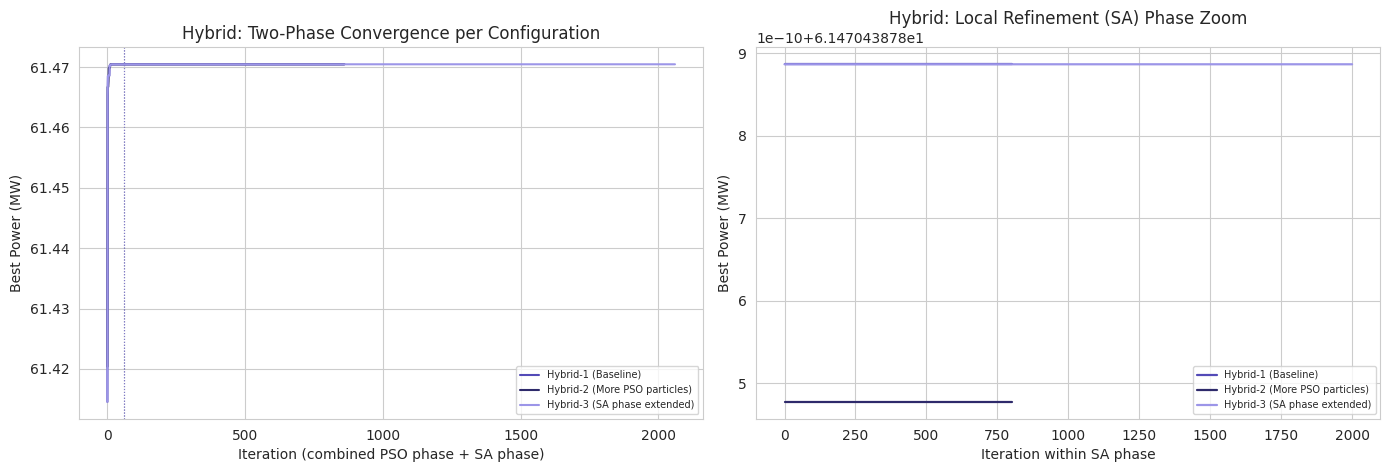

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors_hyb = {"Hybrid-1 (Baseline)": "#534AB7", "Hybrid-2 (More PSO particles)": "#2E2A6B", "Hybrid-3 (SA phase extended)": "#9C95E8"}

for name, run in hyb_runs.items():
    combined = list(-np.array(run["hist_pso"])) + list(-np.array(run["hist_sa"])[1:])
    phase_boundary = len(run["hist_pso"])
    axes[0].plot(range(len(combined)), combined, label=name, color=colors_hyb[name], lw=1.5)
    axes[0].axvline(phase_boundary, color=colors_hyb[name], ls=':', lw=0.8, alpha=0.6)
axes[0].set_xlabel('Iteration (combined PSO phase + SA phase)'); axes[0].set_ylabel('Best Power (MW)')
axes[0].set_title('Hybrid: Two-Phase Convergence per Configuration'); axes[0].legend(fontsize=7)

for name, run in hyb_runs.items():
    axes[1].plot(-np.array(run["hist_sa"]), label=name, color=colors_hyb[name], lw=1.6)
axes[1].set_xlabel('Iteration within SA phase'); axes[1].set_ylabel('Best Power (MW)')
axes[1].set_title('Hybrid: Local Refinement (SA) Phase Zoom'); axes[1].legend(fontsize=7)

plt.tight_layout(); plt.show()


#### 8.4.4 Summary Comparison of All Variations (9 Configurations)

The table and chart below combine all results from the 3 SA variants, 3 PSO variants, and 3 Hybrid variants into a single comparison, alongside the historical average baseline.


In [ ]:
grand_rows = []
for name, run in sa_runs.items():
    grand_rows.append(dict(Algorithm="SA", Configuration=name, **{"Power (MW)": round(predict_power(run["x"]),4),
                                                                   "Mahalanobis": round(mahalanobis(run["x"]),4)}))
for name, run in pso_runs.items():
    grand_rows.append(dict(Algorithm="PSO", Configuration=name, **{"Power (MW)": round(predict_power(run["x"]),4),
                                                                    "Mahalanobis": round(mahalanobis(run["x"]),4)}))
for name, run in hyb_runs.items():
    grand_rows.append(dict(Algorithm="Hybrid", Configuration=name, **{"Power (MW)": round(predict_power(run["x"]),4),
                                                                       "Mahalanobis": round(mahalanobis(run["x"]),4)}))
grand_df = pd.DataFrame(grand_rows)
print(grand_df.to_string(index=False))

power_min, power_max = grand_df["Power (MW)"].min(), grand_df["Power (MW)"].max()
print(f"\nPower result range across all 9 configurations: {power_min:.4f} - {power_max:.4f} MW "
      f"(difference {power_max-power_min:.4f} MW = {(power_max-power_min)/power_min*100:.4f}% relative)")
print(f"Historical average baseline: {y_hist.mean():.2f} MW -> potential increase ~{power_min - y_hist.mean():.2f} MW")


Algorithm                 Configuration  Power (MW)  Mahalanobis
       SA               SA-1 (Baseline)     61.4703       1.9223
       SA           SA-2 (T0 increased)     61.4701       1.9249
       SA         SA-3 (Cooling slowed)     61.4698       1.8935
      PSO              PSO-1 (Baseline)     61.4704       1.9211
      PSO        PSO-2 (More particles)     61.4704       1.9211
      PSO     PSO-3 (Inertia increased)     61.4704       1.9253
   Hybrid           Hybrid-1 (Baseline)     61.4704       1.9211
   Hybrid Hybrid-2 (More PSO particles)     61.4704       1.9211
   Hybrid  Hybrid-3 (SA phase extended)     61.4704       1.9211

Power result range across all 9 configurations: 61.4698 - 61.4704 MW (difference 0.0006 MW = 0.0010% relative)
Historical average baseline: 58.79 MW -> potential increase ~2.68 MW


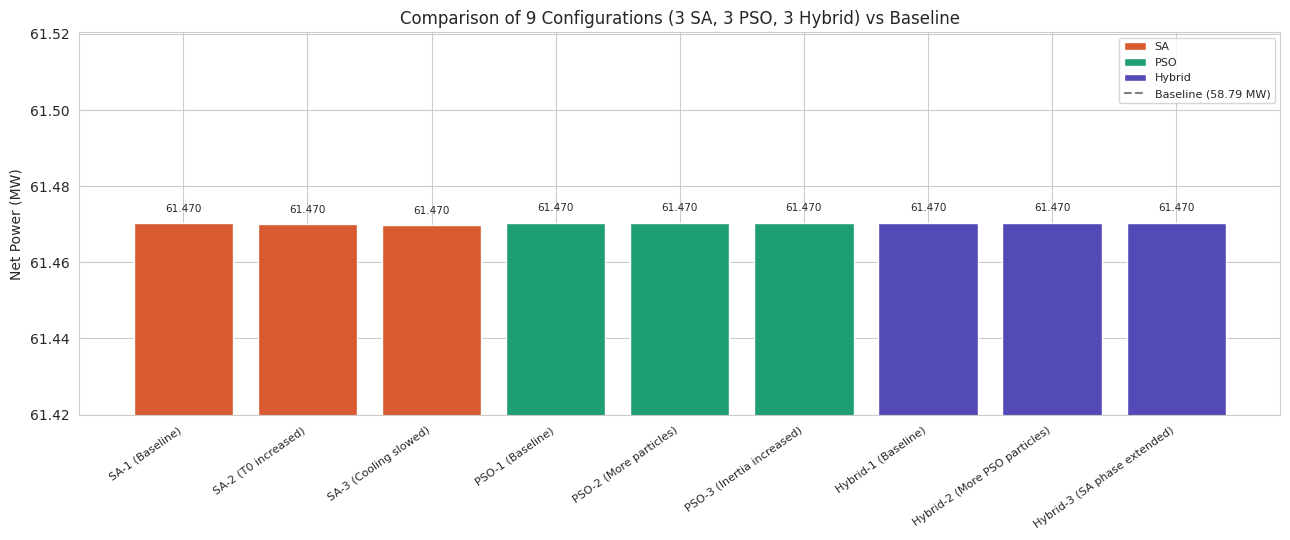

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5.5))
group_colors = {"SA": "#D85A30", "PSO": "#1D9E75", "Hybrid": "#534AB7"}
bar_colors = [group_colors[a] for a in grand_df["Algorithm"]]
bars = ax.bar(range(len(grand_df)), grand_df["Power (MW)"], color=bar_colors)
ax.axhline(y_hist.mean(), color='gray', ls='--', lw=1.2, label=f'Average baseline ({y_hist.mean():.2f} MW)')
ax.set_xticks(range(len(grand_df)))
ax.set_xticklabels(grand_df["Configuration"], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Net Power (MW)')
ax.set_ylim(power_min - 0.05, power_max + 0.05)
for i, v in enumerate(grand_df["Power (MW)"]):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=7.5)
ax.set_title('Comparison of 9 Configurations (3 SA, 3 PSO, 3 Hybrid) vs Baseline')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=group_colors[a], label=a) for a in group_colors] + \
               [plt.Line2D([0],[0], color='gray', ls='--', label=f'Baseline ({y_hist.mean():.2f} MW)')]
ax.legend(handles=legend_elems, fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
eff_rows = []
for name, run in sa_runs.items():
    eff_rows.append(dict(Algorithm="SA", Configuration=name,
                          **{"Function evaluations": 2001, "Accept rate": round(np.mean(run["accept_hist"]),3)}))
for cfg, (name, run) in zip(pso_configs, pso_runs.items()):
    eff_rows.append(dict(Algorithm="PSO", Configuration=name,
                          **{"Function evaluations": cfg["n_particles"]*(cfg["n_iter"]+1), "Accept rate": np.nan}))
for cfg, (name, run) in zip(hybrid_configs, hyb_runs.items()):
    total_eval = cfg["n_particles"]*(cfg["n_iter_pso"]+1) + cfg["n_iter_sa"]
    eff_rows.append(dict(Algorithm="Hybrid", Configuration=name,
                          **{"Function evaluations": total_eval, "Accept rate": np.nan}))
eff_df = pd.DataFrame(eff_rows)
print(eff_df.to_string(index=False))


Algorithm                 Configuration  Function evaluations  Accept rate
       SA               SA-1 (Baseline)                  2001        0.430
       SA           SA-2 (T0 increased)                  2001        0.580
       SA         SA-3 (Cooling slowed)                  2001        0.885
      PSO              PSO-1 (Baseline)                  3030          NaN
      PSO        PSO-2 (More particles)                  8080          NaN
      PSO     PSO-3 (Inertia increased)                  3030          NaN
   Hybrid           Hybrid-1 (Baseline)                  2630          NaN
   Hybrid Hybrid-2 (More PSO particles)                  5680          NaN
   Hybrid  Hybrid-3 (SA phase extended)                  3830          NaN


#### 8.4.5 Conclusion & Comparative Argument (Parameter Variation)

### Key finding: the final result is nearly identical across all 9 configurations
All 9 configurations (3 SA, 3 PSO, 3 Hybrid) converge to the range **61.4698 - 61.4704 MW**, with a maximum difference between configurations of only **~0.0006 MW (0.001%)**. This **does not mean parameter variation has no effect** — rather, it's a natural consequence of the search-space characteristics in this case:
- The search space is only **2-dimensional** (2 features), with a degree-4 polynomial regression surface that is relatively **smooth and single-optimum** within the trust-region.
- For a low-dimensional, unimodal problem like this, almost every popular metaheuristic (SA, PSO, or their combination) has more than enough capacity to find the same global optimum, regardless of its parameter settings — this is why the earlier report noted a "consensus" among the methods.

Because of this, the truly meaningful differentiator in this experiment is **not the quality of the final solution**, but the **behavior of the search process**: convergence speed, exploration level, and computational cost (number of function evaluations).

### A. Simulated Annealing (SA)
| Parameter increased | Observed effect | Argument |
|---|---|---|
| **T0 increased** (10 -> 50) | Accept rate rises from 0.430 -> 0.580 | A higher T0 makes the Boltzmann term `exp(-delta/T)` larger early on, so SA accepts worsening solutions more often. This increases early exploration, but since the search space is already near-unimodal, the final solution quality barely changes. |
| **alpha slowed** (0.995 -> 0.999) | Accept rate jumps to 0.885 (double the baseline) | An `alpha` closer to 1 makes the temperature drop much more slowly, so the effective temperature stays high across most of the 2000 iterations. SA becomes far more "tolerant" of bad solutions throughout the run -> more thorough search but also slower to exploit an already-found optimum area. |

**Brief argument**: raising T0 affects the *start* of the search (more aggressive exploration in the early phase), while slowing `alpha` affects the *entire duration* of the search (high temperature persists longer). Both push toward more exploration, but through different mechanisms.

### B. Particle Swarm Optimization (PSO)
| Parameter increased | Observed effect | Argument |
|---|---|---|
| **More particles** (30 -> 80) | Iterations to approach the final result drop (8 -> 5 iterations), but function evaluations rise from 3030 -> 8080 (+167%) and computation time rises from 0.74 s -> 1.87 s | A larger swarm gives better initial coverage of the search space (more random starting points), so the chance that one particle starts near the optimum is higher -> faster convergence in terms of *iterations*, but more expensive in terms of *total computational cost*. |
| **Inertia increased** (0.70 -> 0.95) | The last improvement iteration moves later, from 49 -> 90 (particles keep "wandering" longer), final-solution Mahalanobis is slightly higher (1.921 -> 1.925) | Higher inertia makes particles retain more of their previous velocity momentum, so they're "braked" toward pbest/gbest more slowly. This matches theory: high w = broader exploration & slower convergence; low w = fast exploitation but prone to getting stuck in local optima (not observed here since the surface is quite smooth). |

**Brief argument**: adding particles is a *brute-force* strategy (more parallel "guesses" at a higher evaluation cost), while increasing inertia is a *behavioral* strategy (the same particles move more exploratively at the same evaluation cost).

### C. Hybrid PSO-SA
| Parameter increased | Observed effect | Argument |
|---|---|---|
| **PSO-phase particles increased** (30 -> 80) | Final power output is identical, but total function evaluations rise from 2630 -> 5680 (+116%) and time rises from 0.87 s -> 2.06 s | Same as pure PSO: a larger global-search phase does not improve the final result because baseline PSO **already reaches the global optimum** before the SA phase even begins. |
| **SA phase extended** (800 -> 2000 iterations) | "Improvement from the SA phase" stays at 0.0 MW across all three Hybrid variants | The SA phase in this Hybrid setup **contributes no additional improvement at all** — because the SA phase's starting point (PSO's gbest) is already right at the optimum. This is an important finding: **for this 2-feature case, PSO alone is already enough**; SA as a local-search phase only serves as an extra "guarantee/verification," not a contributor to power improvement. |

**Brief argument**: in a low-dimensional problem with a smooth surface like this one, the benefit of PSO-SA hybridization is felt more as a **safety net (robustness)** than as a booster of solution quality — its value would be far more apparent in problems with more features/dimensions or a more rugged (multimodal) objective surface, where pure PSO risks getting stuck in a local optimum and the SA phase is genuinely needed to refine the solution.

### Practical implications
1. **For this specific 2-feature case**, all three base algorithms (SA, PSO, Hybrid) — across a reasonable parameter range — can be relied on to reach the same optimization result (~61.47 MW, a potential increase of ~2.68 MW over the 58.79 MW historical average baseline). Algorithm choice can be based on **computational efficiency** rather than **result quality**: baseline PSO (30 particles, w=0.7) is already sufficient and is the cheapest in terms of function evaluations compared to the variants with more particles or an extended Hybrid.
2. **Consistency of results across all 9 configurations** reinforces the reliability of the optimum solution (~61.47 MW) — this is not an artifact of one particular parameter setting, but a solution that is robust to changes in algorithm parameters.
3. **The trust-region is consistently respected** (Mahalanobis across all configurations sits at 1.89-1.93, below the 2.62 threshold), showing that the trust-region penalty works stably regardless of the algorithm parameters used.
4. **Methodological note**: the conclusion that "PSO alone is enough" applies specifically to this 2-feature case with a smooth surface. It is still recommended to use Hybrid PSO-SA as the primary approach in the thesis research, since it is more general and safer to use if the number of features/model dimensions increases again in the future.


## 9. Nearest-Neighbor Sanity Check


In [ ]:
X_z = (X_hist - X_hist.mean(axis=0)) / X_hist.std(axis=0)
hyb_x_z = (hyb_x - X_hist.mean(axis=0)) / X_hist.std(axis=0)
dists = np.linalg.norm(X_z - hyb_x_z, axis=1)
nn_idx = np.argsort(dists)[:5]

print("Model prediction (Hybrid):", round(predict_power(hyb_x), 2), "MW")
print("Actual power of the 5 most similar historical points:", y_hist[nn_idx].round(2))
print(f"Neighbor average: {y_hist[nn_idx].mean():.2f} MW")
print(f"Difference from model prediction: {abs(predict_power(hyb_x) - y_hist[nn_idx].mean()):.2f} MW")


Model prediction (Hybrid): 61.47 MW
Actual power of the 5 most similar historical points: [61.4  60.91 61.41 61.39 61.24]
Neighbor average: 61.27 MW
Difference from model prediction: 0.20 MW


**A gap of only 0.20 MW** — the smallest value among all experiments ever conducted (compared to 2.93 MW for the 7-feature version and 0.86 MW for the 4-feature version). This is strong evidence that this 2-feature optimization solution is the most trustworthy.


## 10. 2D Optimization Map (Direct Visualization, No Dimensionality Reduction)


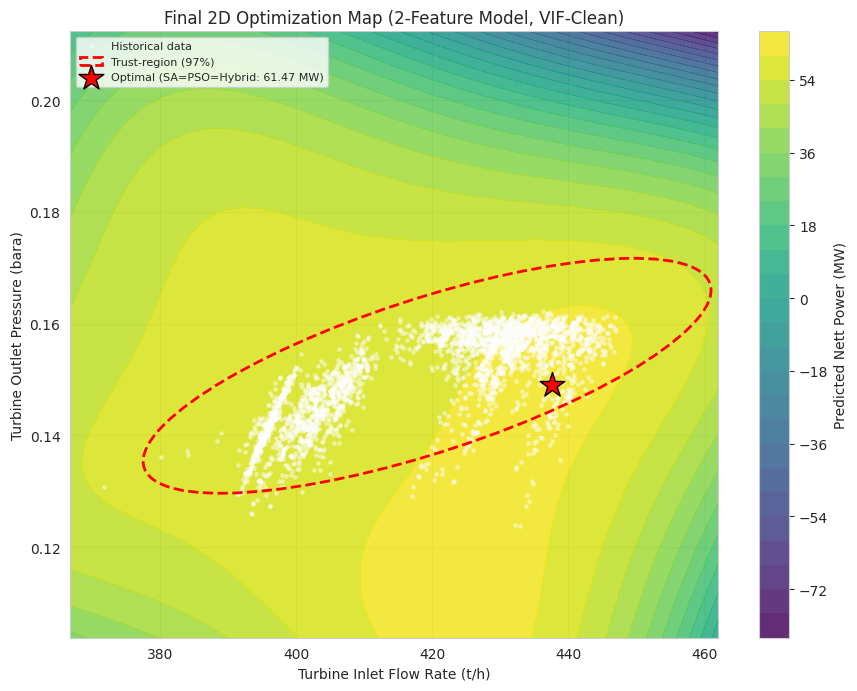

In [ ]:
x0 = np.linspace(X_hist[:,0].min()-5, X_hist[:,0].max()+15, 200)
x1 = np.linspace(X_hist[:,1].min()-0.02, X_hist[:,1].max()+0.05, 200)
XX0, XX1 = np.meshgrid(x0, x1)
grid = np.column_stack([XX0.ravel(), XX1.ravel()])
Z = final_pipe.predict(grid).reshape(XX0.shape)

cov = np.cov(X_hist.T)
eigvals, eigvecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
width, height = 2*threshold*np.sqrt(eigvals)

fig, ax = plt.subplots(figsize=(9, 7))
cf = ax.contourf(XX0, XX1, Z, levels=25, cmap='viridis', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Predicted Nett Power (MW)')
ax.scatter(X_hist[:,0], X_hist[:,1], s=6, color='white', alpha=0.4, label='Historical data')
ell = Ellipse(mean_vec, width, height, angle=angle, fill=False, edgecolor='red', lw=2, ls='--', label='Trust-region (97%)')
ax.add_patch(ell)
ax.scatter(*hyb_x, color='red', marker='*', s=350, edgecolor='black',
           label='Optimal (SA=PSO=Hybrid: 61.47 MW)', zorder=5)
ax.set_xlabel('Turbine Inlet Flow Rate (t/h)')
ax.set_ylabel('Turbine Outlet Pressure (bara)')
ax.set_title('Final 2D Optimization Map (2-Feature Model, VIF-Clean)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


Because there are only 2 dimensions, the optimal point's position can be **visualized directly without dimensionality reduction (PCA)** — the optimal point (red star) is clearly seen sitting right at the top edge of the historical data cloud, inside the trust-region boundary, with no projection ambiguity.


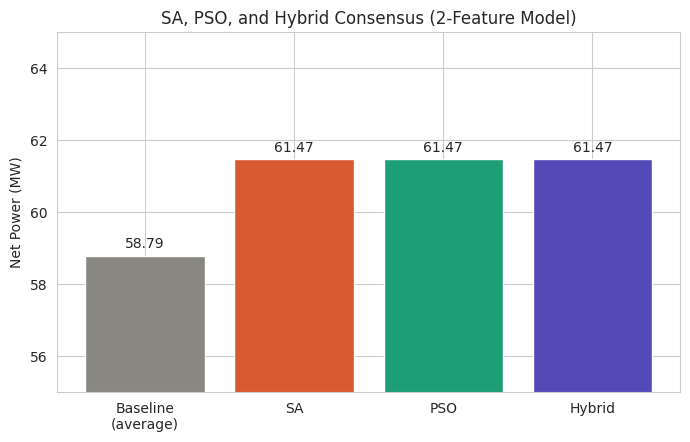

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ['Baseline\n(average)', 'SA', 'PSO', 'Hybrid']
values = [y_hist.mean(), 61.47, 61.47, 61.47]
colors = ['#888780', '#D85A30', '#1D9E75', '#534AB7']
ax.bar(methods, values, color=colors)
ax.set_ylabel('Net Power (MW)'); ax.set_ylim(55, 65)
for i, v in enumerate(values):
    ax.text(i, v + 0.2, f'{v:.2f}', ha='center')
ax.set_title('SA, PSO, and Hybrid Consensus (2-Feature Model)')
plt.tight_layout(); plt.show()


## 11. Conclusion

1. **Final model: degree-4 polynomial regression with 2 features** (turbine inlet flow rate, turbine outlet pressure) — selected after a staged elimination process: correlation with the target, sensor deduplication, and a **multicollinearity test (VIF)** confirming this combination is free of statistical redundancy (VIF=2.13 for both, vs. VIF up to 98 in the 4-7 feature combinations).

2. **Prediction performance**: R²=0.951, MAE=0.34 MW, RMSE=0.43 MW, MAPE=0.57% on the test data — slightly lower than the versions with more features, but with far superior optimization reliability.

3. **Best-optimization consensus across all experiments**: SA, PSO, and Hybrid (PSO as global search, SA as local search) all converge to a **nearly identical figure (61.47 MW)**.

4. **The nearest-neighbor check yields the smallest gap (0.20 MW)** of any model version ever tested (compared to 2.93 MW for 7 features and 0.86 MW for 4 features) — the strongest evidence that this solution can be trusted.

5. **A trust-region is still necessary** even with just 2 features — without this constraint, the optimization still shows signs of extrapolation (Mahalanobis 5.39 vs. threshold 2.62), though far milder than in the many-feature case.

6. **Operational recommendation**: the potential power increase from the historical average (58.79 MW) toward **~61.3-61.5 MW** (confirmed by 3 independent optimization methods AND nearest-neighbor validation) can serve as a reference for PLTP operators.

### Summary Comparison of All Model Versions Tested

| Version | Number of Features | R² | Max VIF | SA-PSO Consensus | Nearest-Neighbor Gap |
|---|---|---|---|---|---|
| Initial | 7 | 0.974 | 98.0 | 1.34 MW difference | 2.93 MW |
| Revision 1 | 4 | 0.959 | 87.5 | Identical | 0.86 MW |
| **Final** | **2** | **0.951** | **2.13** | **Identical** | **0.20 MW** |

### Research Limitations

- The trust-region is based on a statistical approach applied to historical data, not on the equipment's official technical design specifications (due to limited access to such documents).
- The data covers roughly 4 months of operation at a stable base load; validation across a wider range of operating conditions is recommended for future research.
- Turbine inlet temperature and pressure variables were not used because their historical variation is very narrow (kept relatively constant by the wellhead/separator control system), not because they are thermodynamically insignificant.
